In [9]:
# ============================================================
# CELL 1 — Install dependencies
# ============================================================
!pip install ultralytics -q
!pip install yt-dlp -q    # for downloading YouTube videos
!pip install opencv-python-headless -q

import torch
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")

GPU: Tesla T4


In [10]:
# ============================================================
# CELL 2 — Option A: Download video from YouTube
# ============================================================
import subprocess
from pathlib import Path

VIDEO_DIR = Path("/kaggle/working/videos")
VIDEO_DIR.mkdir(exist_ok=True)

# ── Paste any YouTube URL here ────────────────────────────────
# Good search terms:
#   "drone view traffic intersection 4K"
#   "aerial surveillance vehicle detection"
#   "VisDrone dataset video"

YOUTUBE_URL = "https://youtu.be/JqhdBCCUVyQ?si=yk_ZNYjhp8CSKdcX"

# Download at 720p (balance of quality and file size)
result = subprocess.run([
    "yt-dlp",
    "-f", "bestvideo[height<=720][ext=mp4]+bestaudio/best[height<=720]",
    "--merge-output-format", "mp4",
    "-o", str(VIDEO_DIR / "drone_video.%(ext)s"),
    YOUTUBE_URL
], capture_output=False)

# List downloaded files
for f in VIDEO_DIR.glob("*"):
    print(f"  {f.name}  ({f.stat().st_size/1e6:.1f} MB)")

[youtube] Extracting URL: https://youtu.be/JqhdBCCUVyQ?si=yk_ZNYjhp8CSKdcX
[youtube] JqhdBCCUVyQ: Downloading webpage
[youtube] JqhdBCCUVyQ: Downloading android vr player API JSON
[info] JqhdBCCUVyQ: Downloading 1 format(s): 136+251
[download] /kaggle/working/videos/drone_video.mp4 has already been downloaded
  drone_video.mp4  (1.7 MB)


Video: drone_video.mp4
  Resolution : 1280×720
  FPS        : 30.0
  Frames     : 302
  Duration   : 10.1s  (0.2 min)
  Size       : 1.7 MB


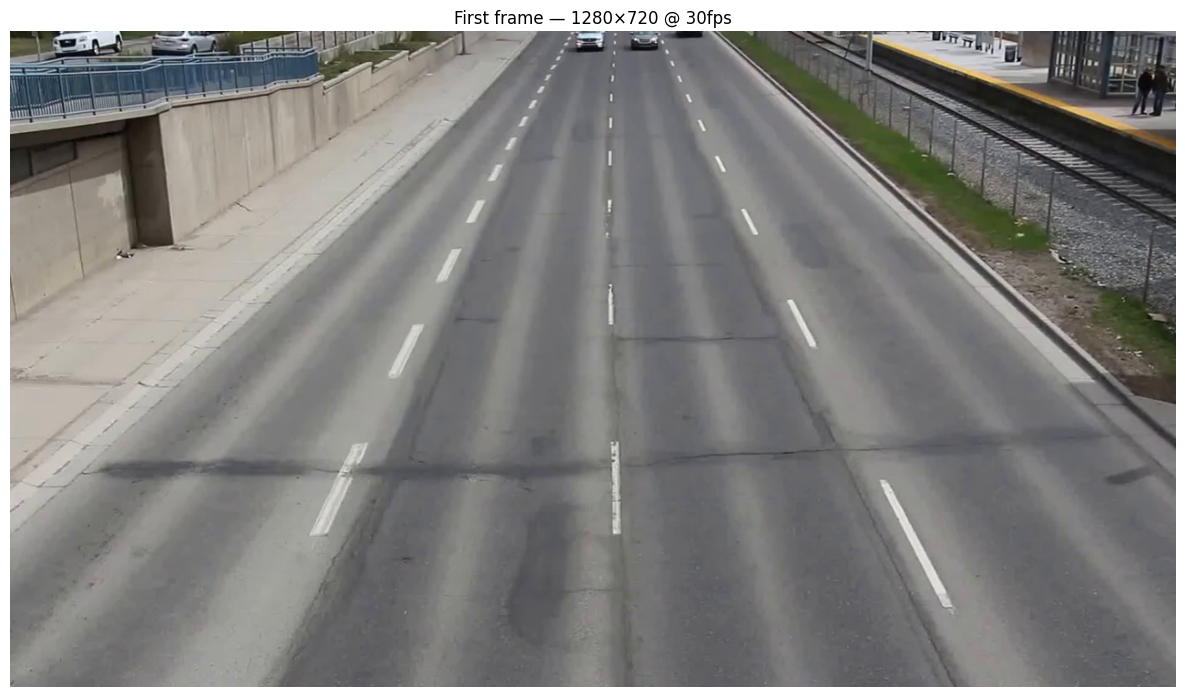

✅ Video loaded successfully


In [11]:
# ============================================================
# CELL 3 — Inspect video properties
# ============================================================
import cv2
from pathlib import Path

VIDEO_PATH = Path("/kaggle/working/videos/drone_video.mp4")
# ↑ update this to your actual video path

cap = cv2.VideoCapture(str(VIDEO_PATH))

fps       = cap.get(cv2.CAP_PROP_FPS)
width     = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height    = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
n_frames  = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
duration  = n_frames / fps

print(f"Video: {VIDEO_PATH.name}")
print(f"  Resolution : {width}×{height}")
print(f"  FPS        : {fps:.1f}")
print(f"  Frames     : {n_frames}")
print(f"  Duration   : {duration:.1f}s  ({duration/60:.1f} min)")
print(f"  Size       : {VIDEO_PATH.stat().st_size/1e6:.1f} MB")

# Show first frame
ret, frame = cap.read()
cap.release()

if ret:
    import matplotlib.pyplot as plt
    plt.figure(figsize=(12, 7))
    plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    plt.title(f"First frame — {width}×{height} @ {fps:.0f}fps")
    plt.axis("off")
    plt.tight_layout()
    plt.savefig("/kaggle/working/first_frame.png", dpi=120)
    plt.show()
    print("✅ Video loaded successfully")

In [12]:
# ============================================================
# CELL 4 — Load your trained RT-DETR model
# ============================================================
import torch
from ultralytics import RTDETR
from pathlib import Path

# Fix PyTorch 2.6
if not hasattr(torch, "_load_patched"):
    _orig = torch.load
    def _patched(*a, **kw):
        kw["weights_only"] = False
        return _orig(*a, **kw)
    torch.load = _patched
    torch._load_patched = True

DEVICE = 0 if torch.cuda.is_available() else "cpu"

# ── Option 1: Use your joint-trained model ────────────────────
CKPT_PATH = Path("/kaggle/working/runs/VisDrone_2x/best.pt")

if CKPT_PATH.exists():
    ckpt = torch.load(str(CKPT_PATH), map_location="cpu",
                      weights_only=False)
    model = RTDETR("rtdetr-l.pt")
    if "rtdetr" in ckpt:
        model.model.load_state_dict(ckpt["rtdetr"], strict=False)
        print("✅ Loaded joint-trained RT-DETR weights")
    else:
        print("⚠️  No rtdetr key — using COCO pretrained weights")
else:
    # ── Option 2: Use COCO pretrained (works out of the box) ──
    print("Using COCO pretrained RT-DETR-L")
    model = RTDETR("rtdetr-l.pt")

# ── Class names ───────────────────────────────────────────────
VD_CLASSES = ["pedestrian","people","bicycle",
              "car","tricycle","motor"]

print(f"Model loaded on device: {DEVICE}")
print(f"Classes: {VD_CLASSES}")

Using COCO pretrained RT-DETR-L
Model loaded on device: 0
Classes: ['pedestrian', 'people', 'bicycle', 'car', 'tricycle', 'motor']


In [13]:
# ============================================================
# CELL 5 — Run RT-DETR inference on video
# Saves output video with bounding boxes drawn
# ============================================================
import cv2
import torch
import numpy as np
from pathlib import Path
from tqdm.notebook import tqdm

VIDEO_PATH  = Path("/kaggle/working/videos/drone_video.mp4")
OUTPUT_PATH = Path("/kaggle/working/output_detected.mp4")

# ── Settings ──────────────────────────────────────────────────
CONF_THRESH   = 0.25    # detection confidence threshold
IOU_THRESH    = 0.45    # NMS IoU threshold
IMGSZ         = 640     # inference image size
SKIP_FRAMES   = 1      # process every Nth frame (1 = all frames)
MAX_FRAMES    = None    # set to e.g. 300 to process only first 300 frames

# ── Class colors (BGR) ────────────────────────────────────────
CLASS_COLORS = {
    0: (255, 100, 100),   # pedestrian — blue
    1: (255, 180,  60),   # people — light blue
    2: (100, 255, 100),   # bicycle — green
    3: (100, 100, 255),   # car — red
    4: (255, 255, 100),   # tricycle — cyan
    5: (180, 100, 255),   # motor — purple
}

cap = cv2.VideoCapture(str(VIDEO_PATH))
fps    = cap.get(cv2.CAP_PROP_FPS)
width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total  = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

# Output video writer
fourcc = cv2.VideoWriter_fourcc(*"mp4v")
out    = cv2.VideoWriter(
    str(OUTPUT_PATH), fourcc,
    fps / SKIP_FRAMES,
    (width, height)
)

print(f"Input : {VIDEO_PATH.name}  {width}×{height}  {fps:.0f}fps")
print(f"Output: {OUTPUT_PATH.name}")
print(f"Processing every {SKIP_FRAMES} frame(s)")
if MAX_FRAMES:
    print(f"Max frames: {MAX_FRAMES}")

frame_idx  = 0
proc_count = 0
det_counts = []

pbar = tqdm(total=min(total, MAX_FRAMES or total),
            desc="Running RT-DETR")

while True:
    ret, frame = cap.read()
    if not ret:
        break
    if MAX_FRAMES and frame_idx >= MAX_FRAMES:
        break

    frame_idx += 1

    # Skip frames for speed
    if frame_idx % SKIP_FRAMES != 0:
        continue

    # ── Run RT-DETR inference ─────────────────────────────────
    results = model.predict(
        source     = frame,
        imgsz      = IMGSZ,
        conf       = CONF_THRESH,
        iou        = IOU_THRESH,
        device     = DEVICE,
        verbose    = False,
        classes    = None,   # detect all classes
    )

    result     = results[0]
    n_detections = len(result.boxes)
    det_counts.append(n_detections)

    # ── Draw detections ───────────────────────────────────────
    annotated = frame.copy()

    for box in result.boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0].cpu().numpy())
        conf  = float(box.conf[0])
        cls   = int(box.cls[0])
        color = CLASS_COLORS.get(cls, (200, 200, 200))
        label = f"{VD_CLASSES[cls] if cls < len(VD_CLASSES) else cls} {conf:.2f}"

        # Box
        cv2.rectangle(annotated, (x1,y1), (x2,y2), color, 2)

        # Label background
        (tw, th), _ = cv2.getTextSize(
            label, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
        cv2.rectangle(annotated,
                      (x1, y1-th-6), (x1+tw+4, y1),
                      color, -1)
        cv2.putText(annotated, label,
                    (x1+2, y1-4),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.5, (255,255,255), 1)

    # ── Stats overlay ─────────────────────────────────────────
    overlay_text = [
        f"Frame: {frame_idx}",
        f"Detections: {n_detections}",
        f"Conf: {CONF_THRESH}",
    ]
    for i, txt in enumerate(overlay_text):
        cv2.putText(annotated, txt,
                    (10, 25 + i*22),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.65, (0,255,0), 2)

    out.write(annotated)
    proc_count += 1
    pbar.update(1)
    pbar.set_postfix({"dets": n_detections})

cap.release()
out.release()
pbar.close()

print(f"\n✅ Done!")
print(f"   Frames processed : {proc_count}")
print(f"   Output saved     : {OUTPUT_PATH}")
print(f"   Output size      : {OUTPUT_PATH.stat().st_size/1e6:.1f} MB")
print(f"   Avg detections   : {np.mean(det_counts):.1f}/frame")
print(f"   Max detections   : {max(det_counts)}/frame")

Input : drone_video.mp4  1280×720  30fps
Output: output_detected.mp4
Processing every 1 frame(s)


Running RT-DETR:   0%|          | 0/302 [00:00<?, ?it/s]


✅ Done!
   Frames processed : 302
   Output saved     : /kaggle/working/output_detected.mp4
   Output size      : 11.6 MB
   Avg detections   : 18.8/frame
   Max detections   : 35/frame


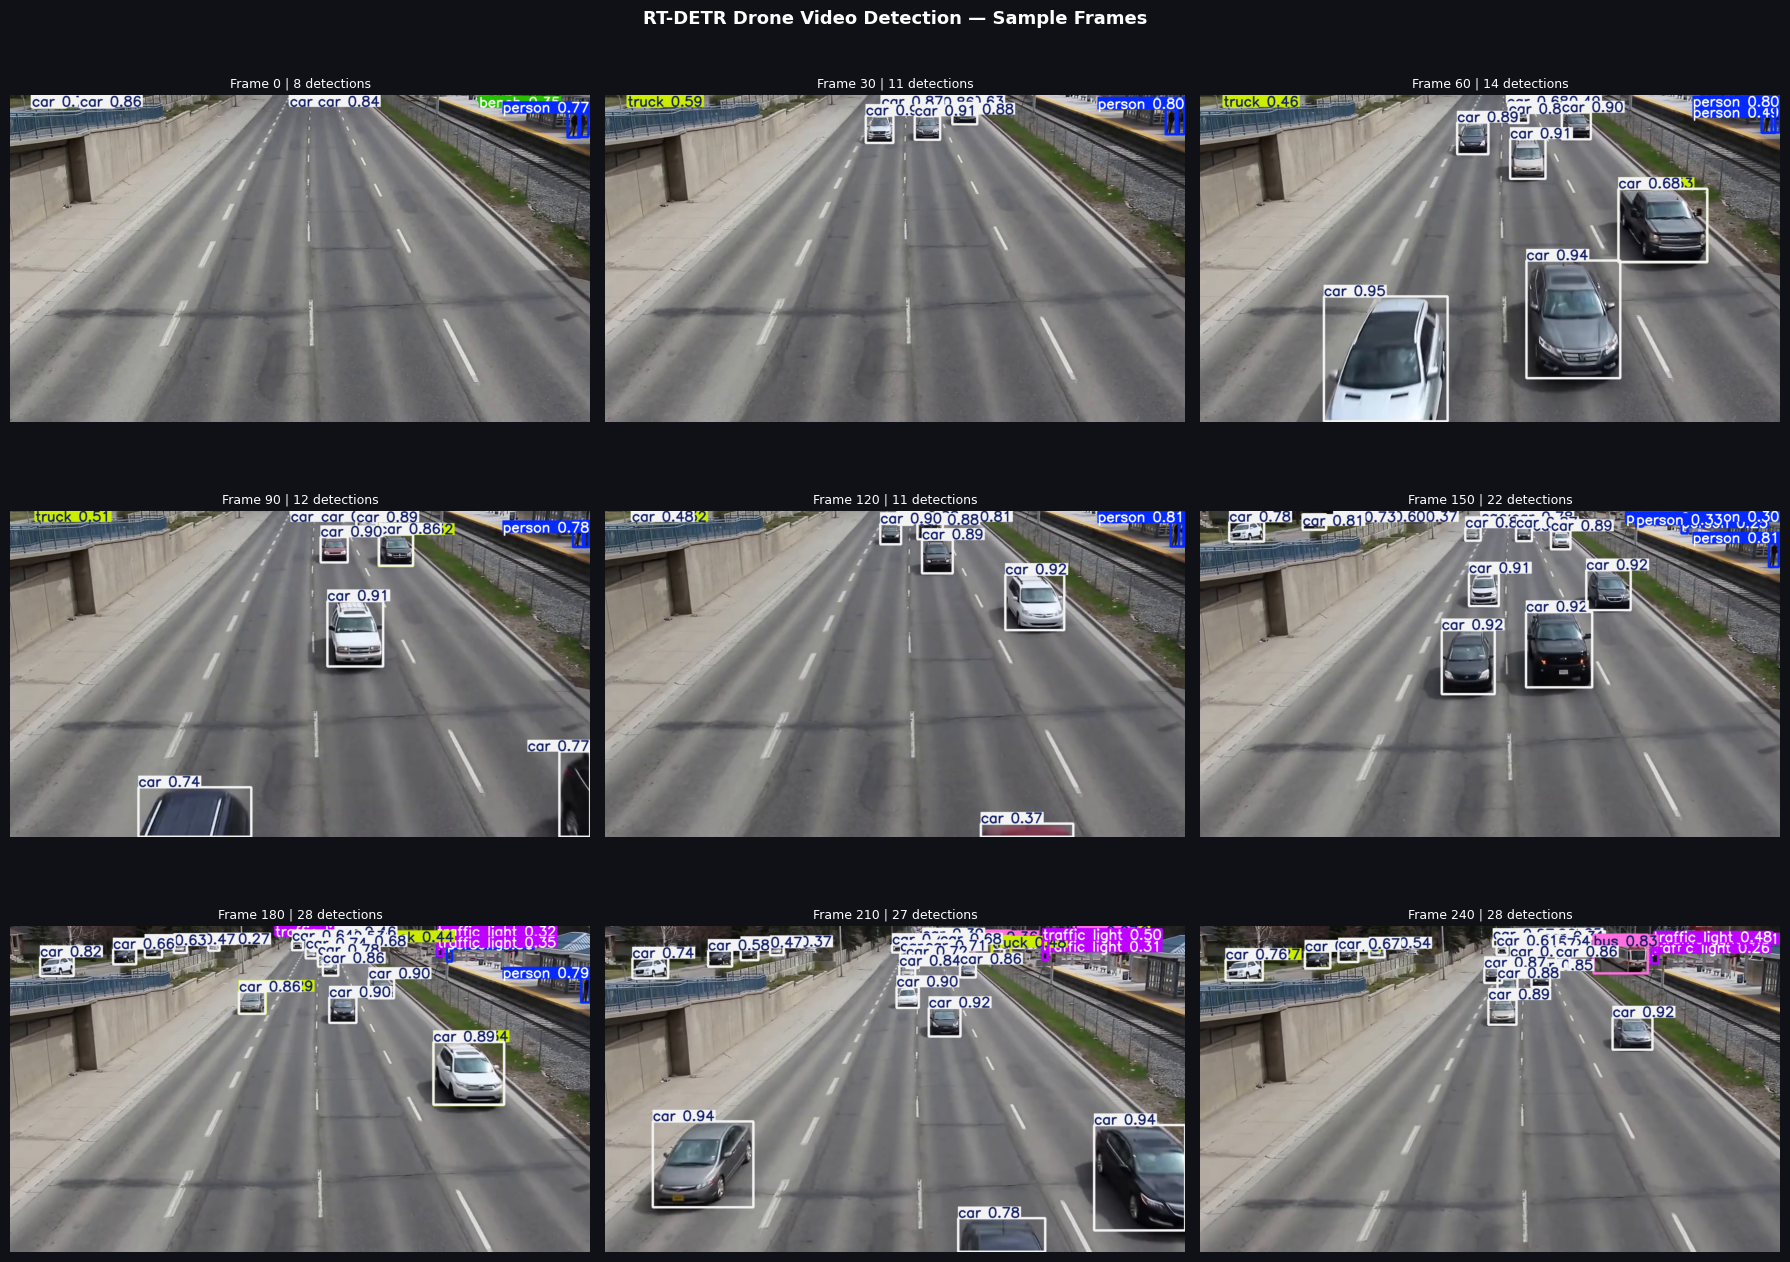

✅ Saved → /kaggle/working/sample_frames.png


In [14]:
# ============================================================
# CELL 6 — Sample frame grid visualization
# Shows 9 detected frames as a grid image
# ============================================================
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

VIDEO_PATH = Path("/kaggle/working/videos/drone_video.mp4")
SAMPLE_EVERY = 30   # grab a frame every N frames

cap    = cv2.VideoCapture(str(VIDEO_PATH))
total  = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
frames = []

for i in range(0, min(total, SAMPLE_EVERY*9), SAMPLE_EVERY):
    cap.set(cv2.CAP_PROP_POS_FRAMES, i)
    ret, frame = cap.read()
    if not ret: break

    results  = model.predict(
        source  = frame,
        imgsz   = IMGSZ,
        conf    = CONF_THRESH,
        device  = DEVICE,
        verbose = False,
    )
    annotated = results[0].plot()   # ultralytics built-in plotting
    frames.append((i, len(results[0].boxes), annotated))

cap.release()

# Plot grid
n     = len(frames)
cols  = 3
rows  = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols,
                         figsize=(cols*6, rows*4.5))
fig.patch.set_facecolor("#0F1117")
axes  = axes.flatten() if n > 1 else [axes]

for ax, (frame_n, n_dets, img) in zip(axes, frames):
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(f"Frame {frame_n} | {n_dets} detections",
                 color="white", fontsize=9)
    ax.axis("off")
    ax.set_facecolor("#1A1D27")

for ax in axes[len(frames):]:
    ax.axis("off")

plt.suptitle(
    "RT-DETR Drone Video Detection — Sample Frames",
    color="white", fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.savefig("/kaggle/working/sample_frames.png",
            dpi=150, bbox_inches="tight",
            facecolor="#0F1117")
plt.show()
print(f"✅ Saved → /kaggle/working/sample_frames.png")

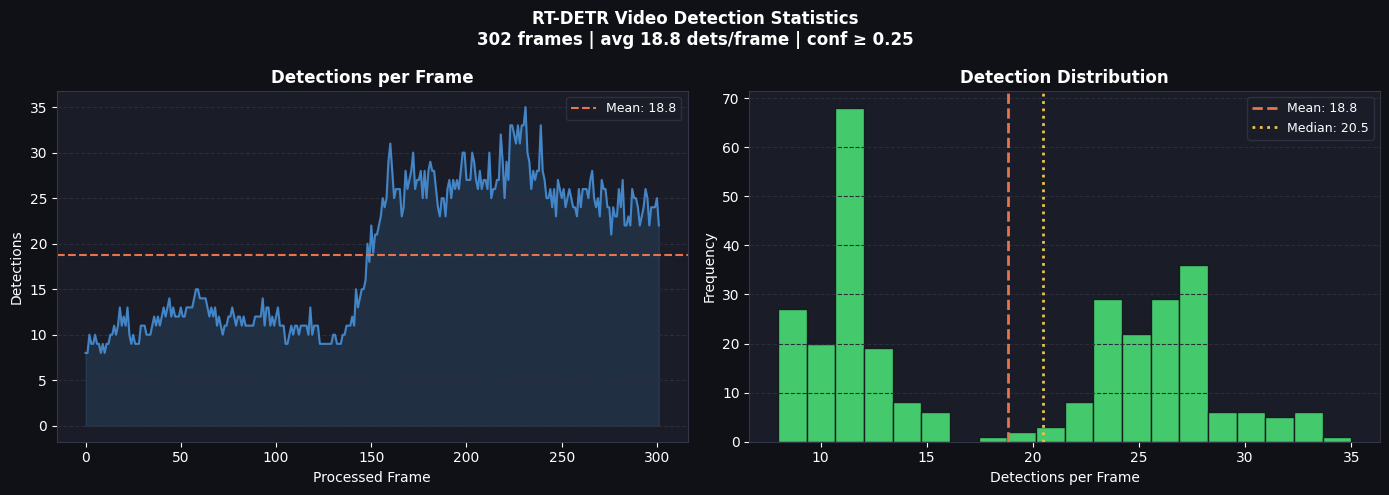

✅ Saved → /kaggle/working/detection_stats.png


In [15]:
# ============================================================
# CELL 7 — Detection statistics plot
# ============================================================
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor("#0F1117")

# ── LEFT — detections per frame ──────────────────────────────
ax1 = axes[0]
ax1.set_facecolor("#1A1D27")
ax1.plot(det_counts, color="#4C9BE8", linewidth=1.5, alpha=0.8)
ax1.fill_between(range(len(det_counts)),
                 det_counts, alpha=0.15, color="#4C9BE8")
ax1.axhline(np.mean(det_counts), color="#E8734C",
            linestyle="--", linewidth=1.5,
            label=f"Mean: {np.mean(det_counts):.1f}")
ax1.set_xlabel("Processed Frame", color="white", fontsize=10)
ax1.set_ylabel("Detections",      color="white", fontsize=10)
ax1.set_title("Detections per Frame",
              color="white", fontsize=12, fontweight="bold")
ax1.tick_params(colors="white")
ax1.spines[["top","right","left","bottom"]].set_color("#333644")
ax1.yaxis.grid(True, color="#2A2D3A", linewidth=0.8,
               linestyle="--")
ax1.legend(fontsize=9, facecolor="#1A1D27",
           labelcolor="white", edgecolor="#333644")

# ── RIGHT — detection count histogram ────────────────────────
ax2 = axes[1]
ax2.set_facecolor("#1A1D27")
ax2.hist(det_counts, bins=20, color="#4CE87A",
         edgecolor="#0F1117", alpha=0.85)
ax2.axvline(np.mean(det_counts), color="#E8734C",
            linestyle="--", linewidth=2,
            label=f"Mean: {np.mean(det_counts):.1f}")
ax2.axvline(np.median(det_counts), color="#E8C44C",
            linestyle=":", linewidth=2,
            label=f"Median: {np.median(det_counts):.1f}")
ax2.set_xlabel("Detections per Frame", color="white", fontsize=10)
ax2.set_ylabel("Frequency",            color="white", fontsize=10)
ax2.set_title("Detection Distribution",
              color="white", fontsize=12, fontweight="bold")
ax2.tick_params(colors="white")
ax2.spines[["top","right","left","bottom"]].set_color("#333644")
ax2.yaxis.grid(True, color="#2A2D3A", linewidth=0.8,
               linestyle="--")
ax2.legend(fontsize=9, facecolor="#1A1D27",
           labelcolor="white", edgecolor="#333644")

plt.suptitle(
    f"RT-DETR Video Detection Statistics\n"
    f"{proc_count} frames | avg {np.mean(det_counts):.1f} dets/frame | "
    f"conf ≥ {CONF_THRESH}",
    color="white", fontsize=12, fontweight="bold"
)
plt.tight_layout()
plt.savefig("/kaggle/working/detection_stats.png",
            dpi=150, bbox_inches="tight",
            facecolor="#0F1117")
plt.show()
print("✅ Saved → /kaggle/working/detection_stats.png")

In [16]:
# ============================================================
# CELL 8 — Download output video from Kaggle
# ============================================================
from IPython.display import FileLink, display

output_files = [
    "/kaggle/working/output_detected.mp4",
    "/kaggle/working/sample_frames.png",
    "/kaggle/working/detection_stats.png",
    "/kaggle/working/first_frame.png",
]

print("📥 Click to download:")
for f in output_files:
    p = Path(f)
    if p.exists():
        display(FileLink(str(p)))
        print(f"  ✅ {p.name}  ({p.stat().st_size/1e6:.1f} MB)")
    else:
        print(f"  ❌ {p.name} not found")

📥 Click to download:


/kaggle/working/output_detected.mp4

  ✅ output_detected.mp4  (11.6 MB)


/kaggle/working/sample_frames.png

  ✅ sample_frames.png  (4.0 MB)


/kaggle/working/detection_stats.png

  ✅ detection_stats.png  (0.1 MB)


/kaggle/working/first_frame.png

  ✅ first_frame.png  (0.8 MB)


In [17]:
# ============================================================
# CELL — NWD-based inference pipeline
# Replaces IoU-NMS with NWD-based duplicate suppression
# NWD is better for tiny objects that may not overlap at all
# ============================================================

import torch
import torch.nn as nn
import numpy as np
import cv2
from pathlib import Path
from ultralytics import RTDETR

# ── NWD between two sets of boxes ────────────────────────────
def compute_nwd_matrix(boxes1, boxes2, C=12.8):
    """
    Compute NWD similarity matrix between two sets of boxes.
    boxes: (N,4) or (M,4) in cx cy w h format (pixel coords)
    Returns: (N,M) NWD similarity matrix, values in [0,1]
    """
    if len(boxes1) == 0 or len(boxes2) == 0:
        return np.zeros((len(boxes1), len(boxes2)))

    boxes1 = np.array(boxes1, dtype=np.float32)
    boxes2 = np.array(boxes2, dtype=np.float32)

    mu1    = boxes1[:, :2]        # (N,2) centres
    sigma1 = boxes1[:, 2:] / 2   # (N,2) half-dims

    mu2    = boxes2[:, :2]        # (M,2) centres
    sigma2 = boxes2[:, 2:] / 2   # (M,2) half-dims

    # Wasserstein-2 distance: broadcast (N,1,2) vs (1,M,2)
    center_dist = ((mu1[:,None,:] - mu2[None,:,:])**2).sum(-1)
    sigma_dist  = ((sigma1[:,None,:] - sigma2[None,:,:])**2).sum(-1)
    w2_dist     = np.sqrt(center_dist + sigma_dist + 1e-7)

    nwd = np.exp(-w2_dist / C)
    return nwd   # (N,M)


def xyxy_to_cxcywh(boxes):
    """Convert [x1,y1,x2,y2] → [cx,cy,w,h]."""
    boxes = np.array(boxes, dtype=np.float32)
    cx = (boxes[:, 0] + boxes[:, 2]) / 2
    cy = (boxes[:, 1] + boxes[:, 3]) / 2
    w  =  boxes[:, 2] - boxes[:, 0]
    h  =  boxes[:, 3] - boxes[:, 1]
    return np.stack([cx, cy, w, h], axis=1)


def nwd_nms(boxes_xyxy, scores, classes,
            nwd_threshold=0.7, C=12.8):
    """
    NWD-based Non-Maximum Suppression.
    Suppresses boxes whose NWD similarity to a higher-scored
    box exceeds nwd_threshold.

    Args:
        boxes_xyxy   : (N,4) in x1 y1 x2 y2 pixel coords
        scores       : (N,) confidence scores
        classes      : (N,) class indices
        nwd_threshold: suppress if NWD > this (like IoU threshold)
        C            : NWD normalisation constant

    Returns:
        keep : list of indices to keep
    """
    if len(boxes_xyxy) == 0:
        return []

    boxes_cxcywh = xyxy_to_cxcywh(boxes_xyxy)
    order        = np.argsort(-scores)   # descending confidence
    keep         = []
    suppressed   = np.zeros(len(boxes_xyxy), dtype=bool)

    for i in order:
        if suppressed[i]:
            continue
        keep.append(i)

        # Compare box i against all remaining boxes
        remaining = [j for j in order
                     if not suppressed[j] and j != i]
        if not remaining:
            continue

        nwd_mat = compute_nwd_matrix(
            boxes_cxcywh[i:i+1],
            boxes_cxcywh[remaining],
            C=C
        )  # shape (1, len(remaining))

        for idx, j in enumerate(remaining):
            # Only suppress same-class boxes
            if (classes[j] == classes[i] and
                    nwd_mat[0, idx] > nwd_threshold):
                suppressed[j] = True

    return keep


print("✅ NWD-NMS functions defined")

✅ NWD-NMS functions defined


In [18]:
# ============================================================
# CELL — NWD confidence scoring
# Re-scores each detection based on NWD similarity to
# its nearest neighbours (density-aware scoring)
# ============================================================

def nwd_confidence_rerank(boxes_xyxy, scores, classes,
                           C=12.8, top_k=5):
    """
    Re-rank detection confidence using NWD neighbourhood density.

    Logic: a detection is more reliable if nearby detections
    (high NWD similarity) from the SAME class also have high
    confidence. This is particularly useful for tiny objects
    where individual detections may be low-confidence but
    a cluster of them is reliable.

    new_score = original_conf * mean(NWD to top_k same-class neighbours)
    """
    if len(boxes_xyxy) == 0:
        return scores

    boxes_cxcywh = xyxy_to_cxcywh(boxes_xyxy)
    scores       = np.array(scores, dtype=np.float32)
    new_scores   = scores.copy()

    for i in range(len(boxes_xyxy)):
        # Find same-class boxes
        same_cls = [j for j in range(len(boxes_xyxy))
                    if classes[j] == classes[i] and j != i]
        if not same_cls:
            continue

        nwd_mat = compute_nwd_matrix(
            boxes_cxcywh[i:i+1],
            boxes_cxcywh[same_cls],
            C=C
        )[0]  # (len(same_cls),)

        # Top-k NWD similarities weighted by neighbour scores
        top_k_actual = min(top_k, len(same_cls))
        top_idx      = np.argsort(-nwd_mat)[:top_k_actual]
        top_nwd      = nwd_mat[top_idx]
        top_conf     = scores[same_cls][top_idx]

        # Weighted average
        if top_nwd.sum() > 0:
            weighted_sim = (top_nwd * top_conf).sum() / top_nwd.sum()
            # Blend original confidence with neighbourhood score
            new_scores[i] = 0.7 * scores[i] + 0.3 * weighted_sim

    return new_scores


print("✅ NWD confidence re-ranking defined")

✅ NWD confidence re-ranking defined


In [19]:
# ============================================================
# CELL — Full NWD inference function
# Drop-in replacement for model.predict()
# ============================================================

def predict_with_nwd(model, frame,
                     conf_thresh    = 0.20,
                     nwd_thresh     = 0.65,
                     nwd_c          = 12.8,
                     imgsz          = 640,
                     device         = 0,
                     use_reranking  = True,
                     class_names    = None):
    """
    Run RT-DETR + NWD-based post-processing.

    Steps:
      1. RT-DETR forward pass (raw predictions, no NMS)
      2. Filter by confidence threshold
      3. NWD confidence re-ranking (optional)
      4. NWD-NMS (replaces standard IoU-NMS)

    Returns dict with keys:
      boxes_xyxy : (N,4) kept boxes in pixel coords
      scores     : (N,) final confidence scores
      classes    : (N,) class indices
      labels     : (N,) class name strings
    """
    # ── Step 1: Raw RT-DETR predictions ─────────────────────
    # agnostic_nms=False, max_det=high to get raw predictions
    results = model.predict(
        source      = frame,
        imgsz       = imgsz,
        conf        = conf_thresh,
        iou         = 0.99,       # ← very high IoU threshold
                                   #   so standard NMS barely removes anything
                                   #   our NWD-NMS will do the suppression
        max_det     = 500,
        device      = device,
        verbose     = False,
    )

    result = results[0]

    if len(result.boxes) == 0:
        return {
            "boxes_xyxy": np.zeros((0,4)),
            "scores"    : np.zeros(0),
            "classes"   : np.zeros(0, dtype=int),
            "labels"    : [],
        }

    boxes_xyxy = result.boxes.xyxy.cpu().numpy()   # (N,4)
    scores     = result.boxes.conf.cpu().numpy()   # (N,)
    classes    = result.boxes.cls.cpu().numpy().astype(int)  # (N,)

    # ── Step 2: NWD confidence re-ranking ───────────────────
    if use_reranking:
        scores = nwd_confidence_rerank(
            boxes_xyxy, scores, classes, C=nwd_c)

    # ── Step 3: NWD-NMS ──────────────────────────────────────
    keep = nwd_nms(boxes_xyxy, scores, classes,
                   nwd_threshold=nwd_thresh, C=nwd_c)

    boxes_xyxy = boxes_xyxy[keep]
    scores     = scores[keep]
    classes    = classes[keep]

    if class_names:
        labels = [f"{class_names[c] if c < len(class_names) else c} "
                  f"{scores[i]:.2f}"
                  for i, c in enumerate(classes)]
    else:
        labels = [f"cls{c} {scores[i]:.2f}"
                  for i, c in enumerate(classes)]

    return {
        "boxes_xyxy": boxes_xyxy,
        "scores"    : scores,
        "classes"   : classes,
        "labels"    : labels,
    }


def draw_nwd_detections(frame, detections,
                         class_colors=None):
    """Draw NWD detections on frame."""
    img = frame.copy()
    DEFAULT_COLORS = [
        (255, 100, 100), (255, 180,  60),
        (100, 255, 100), (100, 100, 255),
        (255, 255, 100), (180, 100, 255),
        (100, 255, 255), (255, 100, 255),
    ]
    for i, (box, label, cls) in enumerate(zip(
            detections["boxes_xyxy"],
            detections["labels"],
            detections["classes"])):
        x1,y1,x2,y2 = map(int, box)
        color = (class_colors or DEFAULT_COLORS)[
            cls % len(class_colors or DEFAULT_COLORS)]

        cv2.rectangle(img, (x1,y1), (x2,y2), color, 2)

        (tw,th), _ = cv2.getTextSize(
            label, cv2.FONT_HERSHEY_SIMPLEX, 0.45, 1)
        cv2.rectangle(img, (x1, y1-th-6),
                      (x1+tw+4, y1), color, -1)
        cv2.putText(img, label, (x1+2, y1-4),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.45, (255,255,255), 1)
    return img


print("✅ predict_with_nwd() and draw_nwd_detections() ready")

✅ predict_with_nwd() and draw_nwd_detections() ready


In [21]:
# ============================================================
# CELL — Run NWD inference on video
# ============================================================

import cv2
import numpy as np
from pathlib import Path
from tqdm.notebook import tqdm

VIDEO_PATH     = Path("/kaggle/working/videos/drone_video.mp4")
OUTPUT_NWD     = Path("/kaggle/working/output_nwd.mp4")
OUTPUT_IOU     = Path("/kaggle/working/output_iou.mp4")   # for comparison

VD_CLASSES = ["pedestrian","people","bicycle",
              "car","tricycle","motor"]

CLASS_COLORS = [
    (255, 100, 100), (255, 180,  60),
    (100, 255, 100), (100, 100, 255),
    (255, 255, 100), (180, 100, 255),
]

# ── Config ────────────────────────────────────────────────────
CONF_THRESH   = 0.20    # lower than IoU pipeline — NWD handles duplicates
NWD_THRESH    = 0.65    # NWD similarity threshold for suppression
NWD_C         = 12.8    # same C as training
IOU_THRESH    = 0.45    # for comparison run
IMGSZ         = 640
SKIP_FRAMES   = 1
MAX_FRAMES    = 300     # set to None for full video

cap    = cv2.VideoCapture(str(VIDEO_PATH))
fps    = cap.get(cv2.CAP_PROP_FPS)
width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total  = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

fourcc   = cv2.VideoWriter_fourcc(*"mp4v")
out_nwd  = cv2.VideoWriter(
    str(OUTPUT_NWD), fourcc, fps/SKIP_FRAMES, (width, height))
out_iou  = cv2.VideoWriter(
    str(OUTPUT_IOU), fourcc, fps/SKIP_FRAMES, (width, height))

nwd_det_counts = []
iou_det_counts = []
frame_idx      = 0

pbar = tqdm(total=min(total, MAX_FRAMES or total),
            desc="NWD vs IoU inference")

while True:
    ret, frame = cap.read()
    if not ret: break
    if MAX_FRAMES and frame_idx >= MAX_FRAMES: break
    frame_idx += 1
    if frame_idx % SKIP_FRAMES != 0: continue

    # ── NWD pipeline ─────────────────────────────────────────
    nwd_dets = predict_with_nwd(
        model, frame,
        conf_thresh   = CONF_THRESH,
        nwd_thresh    = NWD_THRESH,
        nwd_c         = NWD_C,
        imgsz         = IMGSZ,
        device        = DEVICE,
        use_reranking = True,
        class_names   = VD_CLASSES,
    )
    frame_nwd = draw_nwd_detections(frame, nwd_dets, CLASS_COLORS)

    # Overlay label
    cv2.putText(frame_nwd, f"NWD-NMS | {len(nwd_dets['boxes_xyxy'])} dets",
                (10,30), cv2.FONT_HERSHEY_SIMPLEX,
                0.8, (0,255,128), 2)
    cv2.putText(frame_nwd, f"C={NWD_C} thresh={NWD_THRESH}",
                (10,58), cv2.FONT_HERSHEY_SIMPLEX,
                0.6, (0,255,128), 1)
    nwd_det_counts.append(len(nwd_dets["boxes_xyxy"]))

    # ── IoU pipeline (for comparison) ────────────────────────
    iou_results = model.predict(
        source  = frame,
        imgsz   = IMGSZ,
        conf    = CONF_THRESH,
        iou     = IOU_THRESH,
        device  = DEVICE,
        verbose = False,
    )
    frame_iou = iou_results[0].plot()
    cv2.putText(frame_iou,
                f"IoU-NMS | {len(iou_results[0].boxes)} dets",
                (10,30), cv2.FONT_HERSHEY_SIMPLEX,
                0.8, (0,180,255), 2)
    iou_det_counts.append(len(iou_results[0].boxes))

    out_nwd.write(frame_nwd)
    out_iou.write(frame_iou)

    pbar.update(1)
    pbar.set_postfix({
        "NWD": len(nwd_dets["boxes_xyxy"]),
        "IoU": len(iou_results[0].boxes)
    })

cap.release()
out_nwd.release()
out_iou.release()
pbar.close()

print(f"\n✅ Done!")
print(f"   NWD avg dets/frame : {np.mean(nwd_det_counts):.1f}")
print(f"   IoU avg dets/frame : {np.mean(iou_det_counts):.1f}")
print(f"   NWD output : {OUTPUT_NWD}")
print(f"   IoU output : {OUTPUT_IOU}")

NWD vs IoU inference:   0%|          | 0/300 [00:00<?, ?it/s]


✅ Done!
   NWD avg dets/frame : 23.1
   IoU avg dets/frame : 24.4
   NWD output : /kaggle/working/output_nwd.mp4
   IoU output : /kaggle/working/output_iou.mp4


ValueError: too many values to unpack (expected 3)

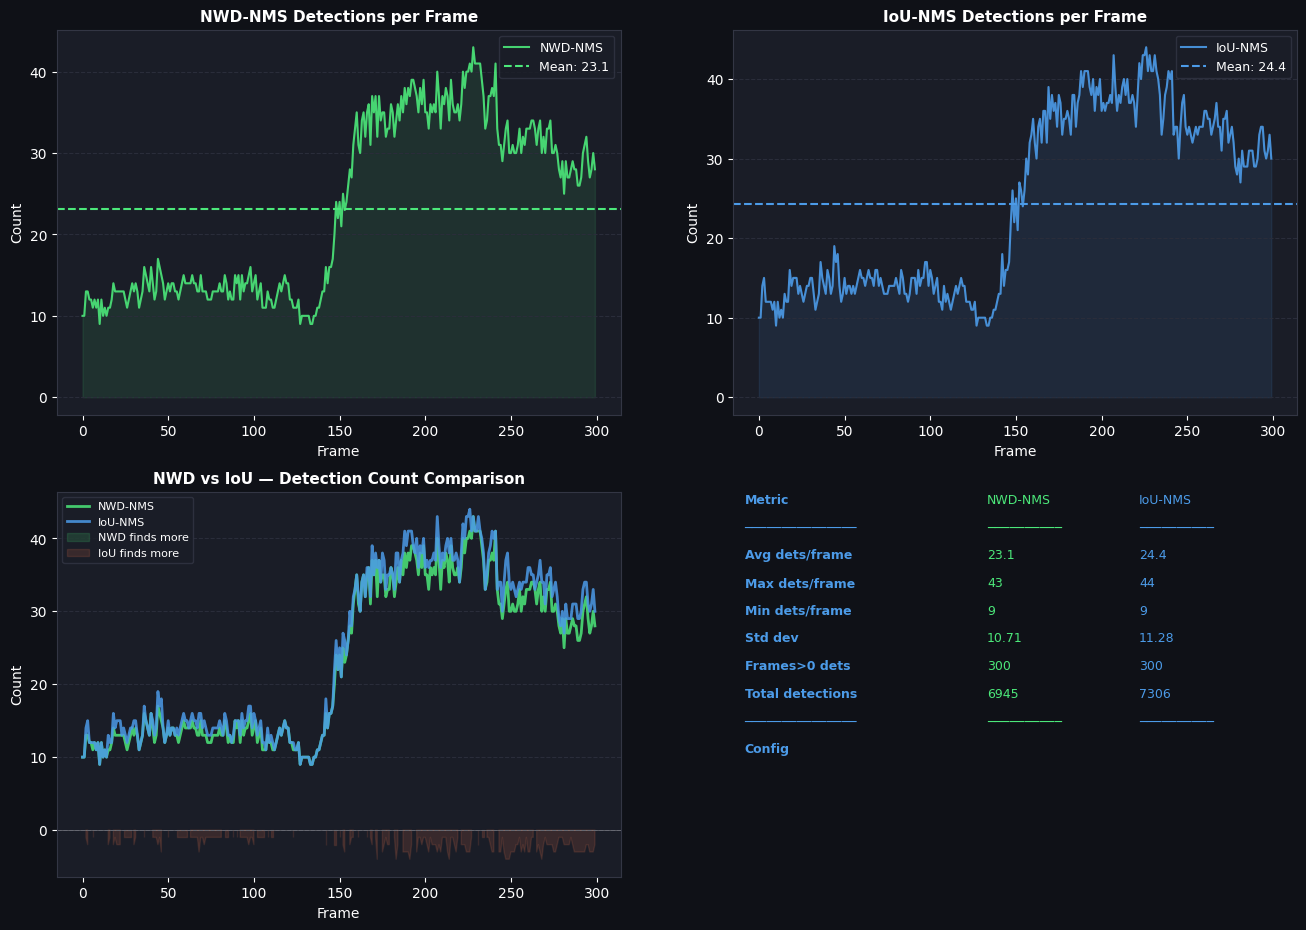

In [22]:
# ============================================================
# CELL — Side-by-side comparison plot: NWD vs IoU
# ============================================================
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.patch.set_facecolor("#0F1117")

# ── TOP LEFT — detections per frame: NWD ─────────────────────
ax = axes[0][0]
ax.set_facecolor("#1A1D27")
ax.plot(nwd_det_counts, color="#4CE87A", linewidth=1.5,
        label="NWD-NMS", alpha=0.9)
ax.axhline(np.mean(nwd_det_counts), color="#4CE87A",
           linestyle="--", linewidth=1.5,
           label=f"Mean: {np.mean(nwd_det_counts):.1f}")
ax.fill_between(range(len(nwd_det_counts)),
                nwd_det_counts, alpha=0.1, color="#4CE87A")
ax.set_title("NWD-NMS Detections per Frame",
             color="white", fontsize=11, fontweight="bold")
ax.set_xlabel("Frame", color="white"); ax.set_ylabel("Count", color="white")
ax.tick_params(colors="white")
ax.spines[["top","right","left","bottom"]].set_color("#333644")
ax.yaxis.grid(True, color="#2A2D3A", linestyle="--")
ax.legend(fontsize=9, facecolor="#1A1D27",
          labelcolor="white", edgecolor="#333644")

# ── TOP RIGHT — detections per frame: IoU ────────────────────
ax = axes[0][1]
ax.set_facecolor("#1A1D27")
ax.plot(iou_det_counts, color="#4C9BE8", linewidth=1.5,
        label="IoU-NMS", alpha=0.9)
ax.axhline(np.mean(iou_det_counts), color="#4C9BE8",
           linestyle="--", linewidth=1.5,
           label=f"Mean: {np.mean(iou_det_counts):.1f}")
ax.fill_between(range(len(iou_det_counts)),
                iou_det_counts, alpha=0.1, color="#4C9BE8")
ax.set_title("IoU-NMS Detections per Frame",
             color="white", fontsize=11, fontweight="bold")
ax.set_xlabel("Frame", color="white"); ax.set_ylabel("Count", color="white")
ax.tick_params(colors="white")
ax.spines[["top","right","left","bottom"]].set_color("#333644")
ax.yaxis.grid(True, color="#2A2D3A", linestyle="--")
ax.legend(fontsize=9, facecolor="#1A1D27",
          labelcolor="white", edgecolor="#333644")

# ── BOTTOM LEFT — overlay comparison ─────────────────────────
ax = axes[1][0]
ax.set_facecolor("#1A1D27")
ax.plot(nwd_det_counts, color="#4CE87A", linewidth=2,
        label="NWD-NMS", alpha=0.85)
ax.plot(iou_det_counts, color="#4C9BE8", linewidth=2,
        label="IoU-NMS", alpha=0.85)
diff = np.array(nwd_det_counts) - np.array(iou_det_counts)
ax.fill_between(range(len(diff)), 0, diff,
                where=diff>0, alpha=0.15, color="#4CE87A",
                label="NWD finds more")
ax.fill_between(range(len(diff)), 0, diff,
                where=diff<0, alpha=0.15, color="#E8734C",
                label="IoU finds more")
ax.axhline(0, color="white", linewidth=0.5, alpha=0.4)
ax.set_title("NWD vs IoU — Detection Count Comparison",
             color="white", fontsize=11, fontweight="bold")
ax.set_xlabel("Frame", color="white"); ax.set_ylabel("Count", color="white")
ax.tick_params(colors="white")
ax.spines[["top","right","left","bottom"]].set_color("#333644")
ax.yaxis.grid(True, color="#2A2D3A", linestyle="--")
ax.legend(fontsize=8, facecolor="#1A1D27",
          labelcolor="white", edgecolor="#333644")

# ── BOTTOM RIGHT — summary stats ──────────────────────────────
ax = axes[1][1]
ax.axis("off")
ax.set_facecolor("#1A1D27")

stats = [
    ("Metric",                "NWD-NMS",          "IoU-NMS"),
    ("─"*15,                  "─"*10,             "─"*10),
    ("Avg dets/frame",
     f"{np.mean(nwd_det_counts):.1f}",
     f"{np.mean(iou_det_counts):.1f}"),
    ("Max dets/frame",
     f"{max(nwd_det_counts)}",
     f"{max(iou_det_counts)}"),
    ("Min dets/frame",
     f"{min(nwd_det_counts)}",
     f"{min(iou_det_counts)}"),
    ("Std dev",
     f"{np.std(nwd_det_counts):.2f}",
     f"{np.std(iou_det_counts):.2f}"),
    ("Frames>0 dets",
     f"{sum(1 for x in nwd_det_counts if x>0)}",
     f"{sum(1 for x in iou_det_counts if x>0)}"),
    ("Total detections",
     f"{sum(nwd_det_counts)}",
     f"{sum(iou_det_counts)}"),
    ("─"*15,                  "─"*10,            "─"*10),
    ("Config",                "",                 ""),
    ("conf thresh",
     f"{CONF_THRESH}",        f"{CONF_THRESH}",  ""),
    ("suppress thresh",
     f"NWD={NWD_THRESH}",     f"IoU={IOU_THRESH}", ""),
    ("NWD C constant",        f"{NWD_C}",         "N/A"),
]

BLUE = "#4C9BE8"; GREEN = "#4CE87A"; WHITE = "white"
y = 0.97
for row in stats:
    col0, col1, col2 = row
    ax.text(0.02, y, col0, transform=ax.transAxes,
            color=BLUE, fontsize=9, fontweight="bold")
    ax.text(0.45, y, col1, transform=ax.transAxes,
            color=GREEN, fontsize=9)
    ax.text(0.72, y, col2, transform=ax.transAxes,
            color=BLUE, fontsize=9)
    y -= 0.072

ax.set_title("Summary Statistics",
             color="white", fontsize=11, fontweight="bold")

plt.suptitle(
    "RT-DETR Video Inference: NWD-NMS vs IoU-NMS\n"
    "NWD better preserves nearby tiny objects that don't overlap",
    color="white", fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.savefig("/kaggle/working/nwd_vs_iou_comparison.png",
            dpi=150, bbox_inches="tight", facecolor="#0F1117")
plt.show()
print("✅ Saved → /kaggle/working/nwd_vs_iou_comparison.png")

In [24]:
# ============================================================
# CELL — Download all outputs
# ============================================================
from IPython.display import FileLink, display

files = [
    "/kaggle/working/output_nwd.mp4",
    "/kaggle/working/output_iou.mp4",
    "/kaggle/working/nwd_vs_iou_comparison.png",
    "/kaggle/working/nwd_vs_iou_frames.png",
]
print("📥 Download:")
for f in files:
    p = Path(f)
    if p.exists():
        display(FileLink(str(p)))
        print(f"  ✅ {p.name}  ({p.stat().st_size/1e6:.1f} MB)")
    else:
        print(f"  ❌ {p.name} not found")

📥 Download:


/kaggle/working/output_nwd.mp4

  ✅ output_nwd.mp4  (12.2 MB)


/kaggle/working/output_iou.mp4

  ✅ output_iou.mp4  (14.1 MB)
  ❌ nwd_vs_iou_comparison.png not found
  ❌ nwd_vs_iou_frames.png not found
